Dataset Shape : (300, 2)


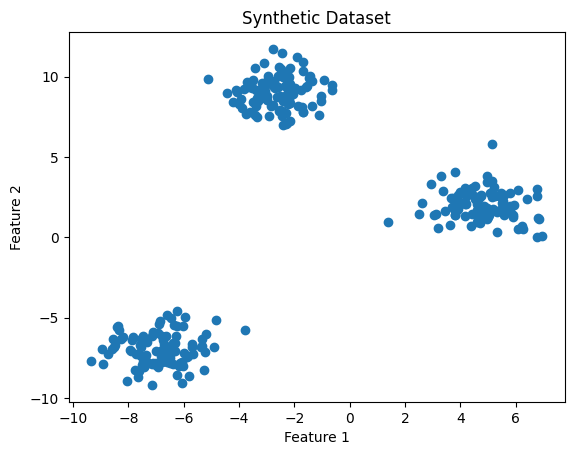

Model Training Completed
Cluster Labels :
[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]
Cluster Centers :
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]
Silhouette Score : 0.8480303059596955


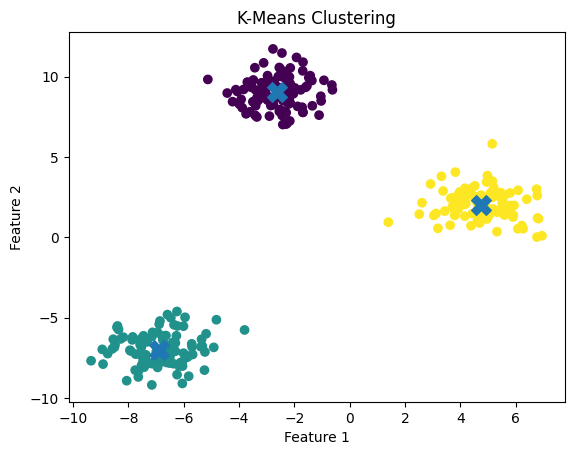

In [1]:
# ============================================================
# K-MEANS CLUSTERING
# ============================================================

# K-Means:
# Unsupervised Machine Learning Algorithm
# Groups similar data points into clusters

# ============================================================
# STEP 1 : Import Required Libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# STEP 2 : Generate Synthetic Dataset
# ============================================================

# make_blobs creates artificial clustered data

X, y = make_blobs(
    n_samples=300,      # Total data points
    centers=3,          # Number of clusters
    n_features=2,       # Number of features
    random_state=42
)

print("Dataset Shape :", X.shape)

# ============================================================
# STEP 3 : Visualize Dataset
# ============================================================

plt.scatter(X[:,0], X[:,1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset")

plt.show()

# ============================================================
# STEP 4 : Create K-Means Model
# ============================================================

kmeans = KMeans(
    n_clusters=3,       # Number of clusters
    random_state=42
)

# ============================================================
# STEP 5 : Train Model
# ============================================================

kmeans.fit(X)

print("Model Training Completed")

# ============================================================
# STEP 6 : Predict Clusters
# ============================================================

clusters = kmeans.predict(X)

print("Cluster Labels :")
print(clusters)

# ============================================================
# STEP 7 : Print Cluster Centers
# ============================================================

print("Cluster Centers :")

print(kmeans.cluster_centers_)

# ============================================================
# STEP 8 : Evaluate Model
# ============================================================

# Silhouette Score:
# Measures clustering quality
# Closer to 1 -> Better clustering

score = silhouette_score(X, clusters)

print("Silhouette Score :", score)

# ============================================================
# STEP 9 : Visualize Final Clusters
# ============================================================

plt.scatter(X[:,0], X[:,1], c=clusters)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

Dataset :
[['Red' 'Small']
 ['Red' 'Medium']
 ['Blue' 'Small']
 ['Blue' 'Large']
 ['Green' 'Medium']
 ['Green' 'Large']]
Model Training Completed
Cluster Labels :
[1 0 1 2 0 0]
Cluster Centroids :
[['Green' 'Medium']
 ['Blue' 'Small']
 ['Blue' 'Large']]
   Color    Size  Cluster
0    Red   Small        1
1    Red  Medium        0
2   Blue   Small        1
3   Blue   Large        2
4  Green  Medium        0
5  Green   Large        0


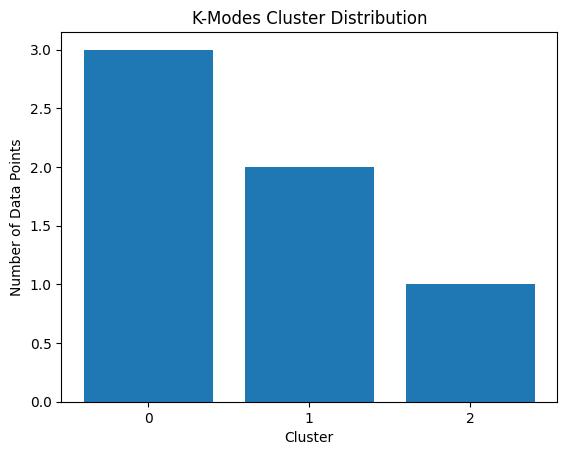

In [8]:
# ============================================================
# K-MODES CLUSTERING
# ============================================================

# K-Modes:
# Used for categorical data
# Similar to K-Means but uses MODE instead of MEAN

# ============================================================
# STEP 1 : Install Library
# ============================================================

# Run once if not installed

# pip install kmodes

# ============================================================
# STEP 2 : Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd

from kmodes.kmodes import KModes

# ============================================================
# STEP 3 : Create Synthetic Categorical Dataset
# ============================================================

# Categorical data example

data = np.array([
    ['Red', 'Small'],
    ['Red', 'Medium'],
    ['Blue', 'Small'],
    ['Blue', 'Large'],
    ['Green', 'Medium'],
    ['Green', 'Large']
])

print("Dataset :")

print(data)

# ============================================================
# STEP 4 : Create K-Modes Model
# ============================================================

kmodes = KModes(
    n_clusters=3,       # Number of clusters
    init='Huang',       # Initialization method
    random_state=42
)

# ============================================================
# STEP 5 : Train Model
# ============================================================

clusters = kmodes.fit_predict(data)

print("Model Training Completed")

# ============================================================
# STEP 6 : Print Cluster Labels
# ============================================================

print("Cluster Labels :")

print(clusters)

# ============================================================
# STEP 7 : Print Cluster Centroids
# ============================================================

print("Cluster Centroids :")

print(kmodes.cluster_centroids_)

# ============================================================
# STEP 8 : Display Final Clustered Data
# ============================================================

df = pd.DataFrame(
    data,
    columns=['Color', 'Size']
)

df['Cluster'] = clusters

print(df)

# ============================================================
# STEP 9 : Visualize Cluster Distribution
# ============================================================

import matplotlib.pyplot as plt

cluster_counts = df['Cluster'].value_counts()

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Data Points")
plt.title("K-Modes Cluster Distribution")

plt.show()